In [53]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset
import deepinv as dinv
import matplotlib.pyplot as plt
import torch.optim as optim

In [54]:
class DeepInvTomographicMNIST(Dataset):
    def __init__(self, root='./data', train=True, download=True, device='cuda'):
        
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        
        self.mnist = datasets.MNIST(
            root=root, 
            train=train, 
            download=download, 
            transform=transforms.ToTensor()
        )
        
        self.angles = torch.linspace(0, torch.pi, steps=5, device=self.device)
        
        self.physics = dinv.physics.Tomography(
            img_width=28, 
            angles=self.angles, 
            circle=False,
            device=self.device,
            normalize=True,
            noise_model=dinv.physics.GaussianNoise(sigma=0.5),
        )
        
        # Base photon intensity 
        self.i0 = 60.0 

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        image, label = self.mnist[idx]
        x = image.unsqueeze(0).to(self.device) 
        sinogram = self.physics(x)
        sinogram = sinogram.squeeze(0)
        y=sinogram
        # Crop to exactly 25 lines/angle
        # center = sinogram.shape[-1] // 2
        # sinogram = sinogram[..., center-12 : center+13] 
        
        # # Compute mean photon count and sample Poisson noise 
        # mean_photons = self.i0 * torch.exp(-sinogram)
        # y = torch.poisson(mean_photons)
        
        # Return Y (measurement), X (image), and Z (label)
        label_tensor = torch.tensor(label, device=self.device)
        
        return y, x.squeeze(0), label_tensor

In [55]:
full_train_dataset = DeepInvTomographicMNIST(train=True, device='cuda')
full_test_dataset = DeepInvTomographicMNIST(train=False, device='cuda')
num_train_samples = 1000  # out of 60,000
num_test_samples = 500   # out of 10,000

train_subset = Subset(full_train_dataset, indices=range(num_train_samples))
test_subset = Subset(full_test_dataset, indices=range(num_test_samples))

batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

y, images, labels = next(iter(train_loader))

print(f"Measurements (Y) device: {y.device}, shape: {y.shape}")
print(f"Images (X) device: {images.device}, shape: {images.shape}")
print(f"Labels device: {labels.device}, shape: {labels.shape}")

Measurements (Y) device: cuda:0, shape: torch.Size([64, 1, 40, 5])
Images (X) device: cuda:0, shape: torch.Size([64, 1, 28, 28])
Labels device: cuda:0, shape: torch.Size([64])


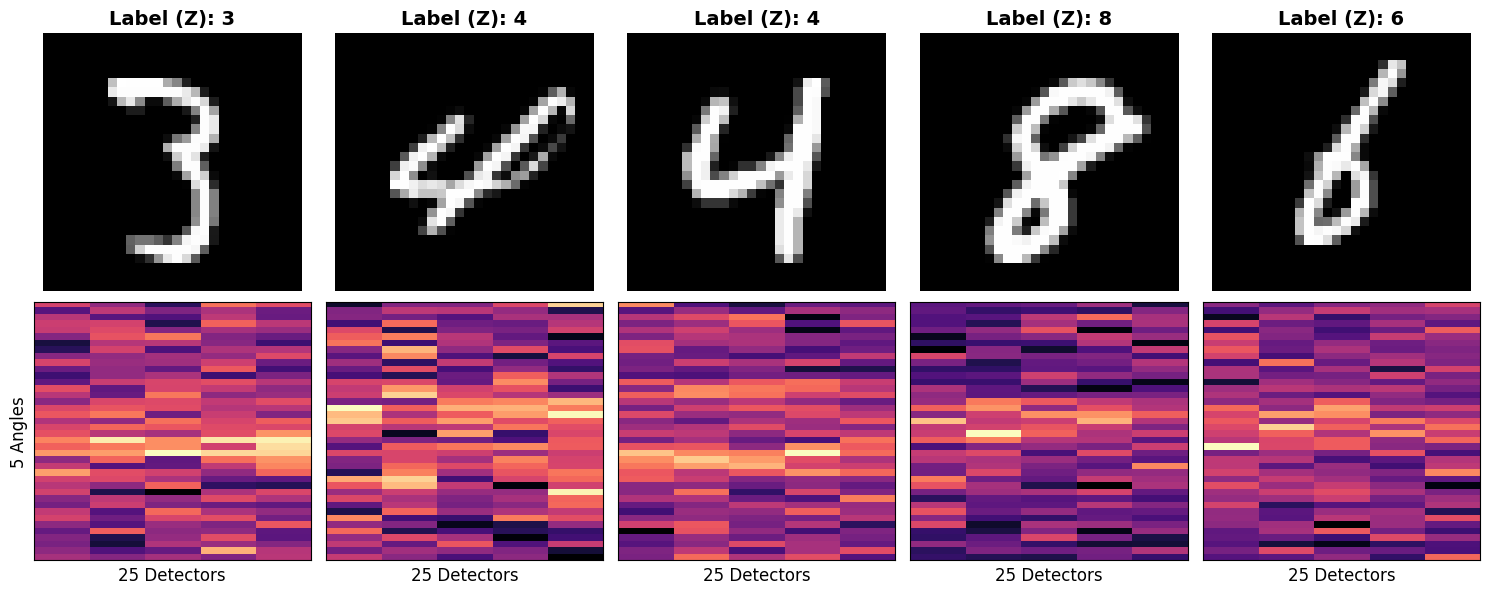

In [56]:
num_samples = 5

fig, axes = plt.subplots(nrows=2, ncols=num_samples, figsize=(15, 6))

for i in range(num_samples):
    img_np = images[i].squeeze().cpu().numpy()
    y_np = y[i].squeeze().cpu().numpy()
    
    label_val = labels[i].item()
    ax_img = axes[0, i]
    ax_img.imshow(img_np, cmap='gray')
    ax_img.set_title(f"Label (Z): {label_val}", fontsize=14, fontweight='bold')
    ax_img.axis('off')
    ax_meas = axes[1, i]
    im = ax_meas.imshow(y_np, cmap='magma', aspect='auto') 
    
    if i == 0:
        ax_meas.set_ylabel("5 Angles", fontsize=12)
    ax_meas.set_xlabel("25 Detectors", fontsize=12)
    ax_meas.set_xticks([])
    ax_meas.set_yticks([])

plt.tight_layout()
plt.show()

### Task model for images to digits (Classifier)

In [57]:
import torch
import torch.nn as nn

class TaskNet(nn.Module):
    def __init__(self):
        super(TaskNet, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Linear(128 * 3 * 3, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1) 
        logits = self.fc(x)
        return logits

In [60]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
task_net = TaskNet().to(device) 
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(task_net.parameters(), lr=1e-3)
num_epochs = 20

print("Starting TaskNet Pre-training on Clean Images (X -> Z)...")

for epoch in range(num_epochs):
    task_net.train() 
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (y, images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = task_net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1) 
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_epoch_loss = running_loss / len(train_loader)
    train_epoch_acc = 100 * correct / total
    
    # --- Evaluation Phase ---
    task_net.eval() 
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for y, images, labels in test_loader:
            outputs = task_net(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
    test_epoch_acc = 100 * test_correct / test_total
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_acc:.2f}% | Test Acc: {test_epoch_acc:.2f}%")


Starting TaskNet Pre-training on Clean Images (X -> Z)...
Epoch [1/20] | Train Loss: 2.1793 | Train Acc: 26.30% | Test Acc: 58.00%
Epoch [2/20] | Train Loss: 1.2212 | Train Acc: 71.50% | Test Acc: 77.40%
Epoch [3/20] | Train Loss: 0.5567 | Train Acc: 83.30% | Test Acc: 82.20%
Epoch [4/20] | Train Loss: 0.3697 | Train Acc: 88.70% | Test Acc: 87.80%
Epoch [5/20] | Train Loss: 0.2595 | Train Acc: 93.10% | Test Acc: 90.60%
Epoch [6/20] | Train Loss: 0.1972 | Train Acc: 94.70% | Test Acc: 93.60%
Epoch [7/20] | Train Loss: 0.1599 | Train Acc: 95.40% | Test Acc: 94.00%
Epoch [8/20] | Train Loss: 0.1358 | Train Acc: 95.80% | Test Acc: 92.80%
Epoch [9/20] | Train Loss: 0.1152 | Train Acc: 96.50% | Test Acc: 93.00%
Epoch [10/20] | Train Loss: 0.0991 | Train Acc: 96.80% | Test Acc: 95.20%
Epoch [11/20] | Train Loss: 0.0809 | Train Acc: 97.80% | Test Acc: 93.60%
Epoch [12/20] | Train Loss: 0.0965 | Train Acc: 97.00% | Test Acc: 94.00%
Epoch [13/20] | Train Loss: 0.0495 | Train Acc: 98.60% | Test A

## Sequential Learning

In [81]:
import torch
import torch.nn as nn

class OverallReconBlock(nn.Module):
    def __init__(self, in_features=125, out_res=28):
        """
        Overall Reconstruction Block (A_theta_dagger)
        - in_features: num_angles * num_detectors (5 * 25 = 125)
        - out_res: Output image resolution (28x28 for MNIST)
        """
        super(OverallReconBlock, self).__init__()
        self.out_res = out_res
        
        # --- Step A: Learned Global Projection ---
        # Maps raw 1D tomographic data to a rough 2D image estimate
        self.fc_projector = nn.Sequential(
            nn.Linear(in_features, out_res * out_res),
            nn.ReLU(inplace=True)
        )
        
        # --- Step B: U-Net Refinement Block ---
        # Encoder
        self.enc1 = self._conv_block(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = self._conv_block(32, 64)
        
        # Decoder
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(64, 32) # 32 (up) + 32 (skip)
        
        # Final Output Layer
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1)

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, y):
        # 1. Flatten measurements: (B, 1, 5, 25) -> (B, 125)
        y_flat = y.view(y.size(0), -1)
        
        # 2. Project to initial image: (B, 784) -> (B, 1, 28, 28)
        x_init = self.fc_projector(y_flat).view(-1, 1, self.out_res, self.out_res)
        
        # 3. U-Net Refinement with Skip Connections
        s1 = self.enc1(x_init)
        p1 = self.pool1(s1)
        
        b = self.bottleneck(p1)
        
        d1 = self.up1(b)
        merge1 = torch.cat([d1, s1], dim=1)
        
        x_refined = self.dec1(merge1)
        x_final = self.final_conv(x_refined)
        
        return x_final

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
recon_block = OverallReconBlock().to(device)

print(f"Recon Block initialized on {device}.")

Recon Block initialized on cuda.


### Step 1 : Reconstruction of image

In [82]:
import torch.nn as nn
import torch.optim as optim

# 1. Initialize the UPGRADED model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Ensure you use the name of the new class we just defined
recon_net = OverallReconBlock().to(device) 

# 2. Setup Loss and Optimizer for the new parameters
# The paper uses squared L2-distance for the reconstruction loss
criterion_mse = nn.MSELoss() 
optimizer_recon = optim.Adam(recon_net.parameters(), lr=1e-3)

num_epochs_recon = 30

print(f"Starting OverallReconBlock Training on {device}...")

for epoch in range(num_epochs_recon):
    # --- Training Phase ---
    recon_net.train()
    running_loss = 0.0
    
    for y, images, labels in train_loader:
        # Move data to GPU and ensure correct type
        y = y.float().to(device)
        images = images.to(device)
        
        optimizer_recon.zero_grad()
        
        # Forward pass
        reconstructed_x = recon_net(y)
        
        # Calculate reconstruction loss (MSE)
        loss = criterion_mse(reconstructed_x, images)
        
        # Backward pass
        loss.backward()
        optimizer_recon.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    
    # --- Validation Phase ---
    recon_net.eval()
    val_loss = 0.0
    with torch.no_grad():
        for y, images, labels in test_loader:
            y = y.float().to(device)
            images = images.to(device)
            
            reconstructed_x = recon_net(y)
            val_loss += criterion_mse(reconstructed_x, images).item()
            
    val_loss /= len(test_loader)
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs_recon}] | Train MSE: {epoch_loss:.6f} | Val MSE: {val_loss:.6f}")

print("Training Complete!")

Starting OverallReconBlock Training on cuda...


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x200 and 125x784)

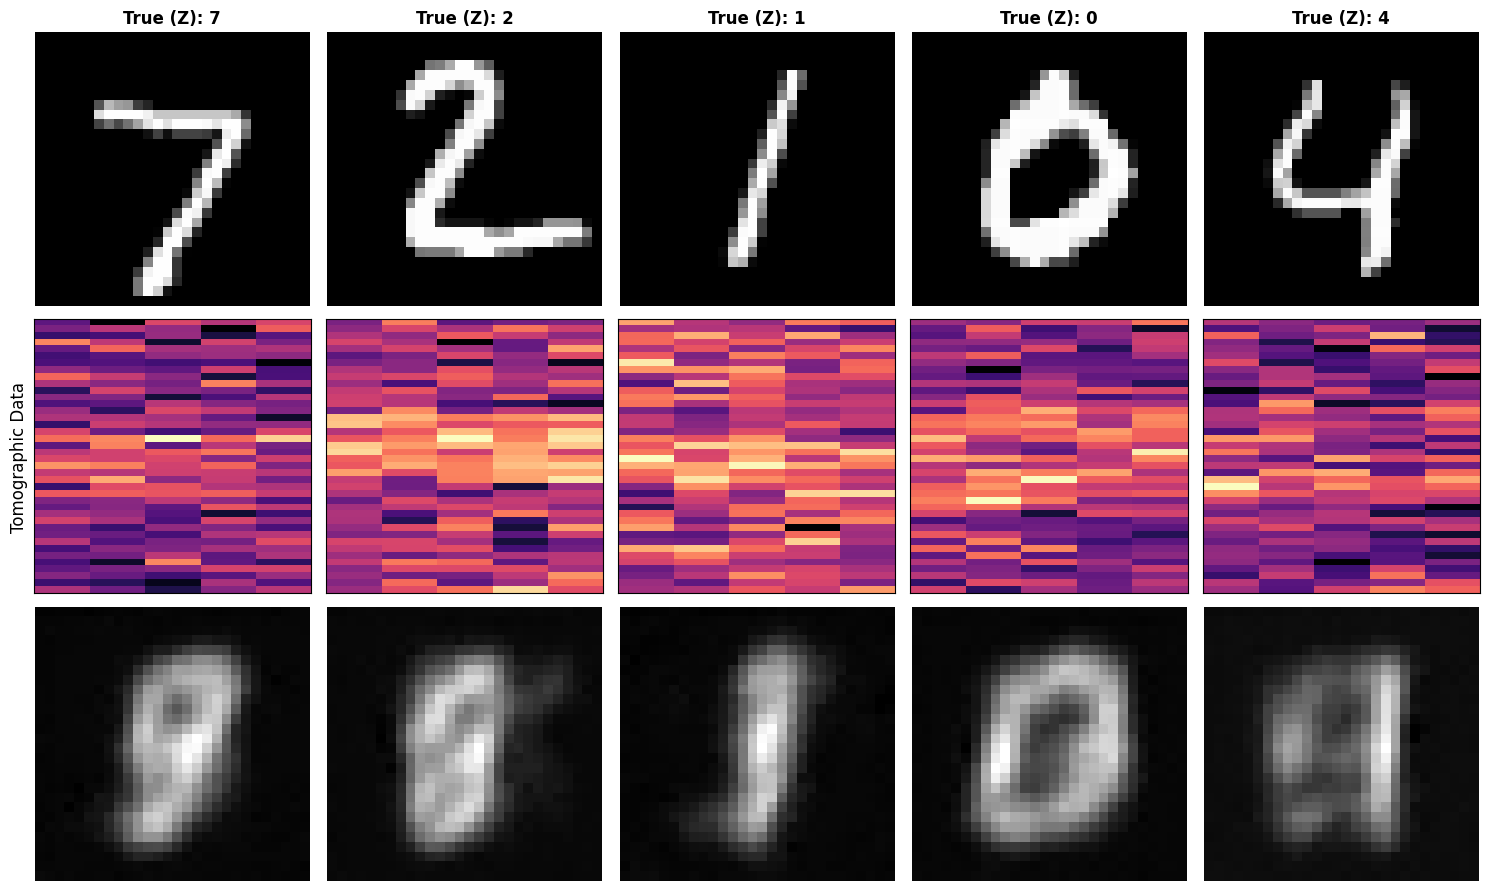

In [69]:
recon_net.eval()

y_val, x_val, labels_val = next(iter(test_loader))
y_val = y_val.float().to(device)

with torch.no_grad():
    x_hat = recon_net(y_val)

num_samples = 5
fig, axes = plt.subplots(nrows=3, ncols=num_samples, figsize=(15, 9))

for i in range(num_samples):
    y_np = y_val[i].squeeze().cpu().numpy()
    x_true_np = x_val[i].squeeze().cpu().numpy()
    x_recon_np = x_hat[i].squeeze().cpu().numpy()
    label_val = labels_val[i].item()
    
    ax_true = axes[0, i]
    ax_true.imshow(x_true_np, cmap='gray')
    ax_true.set_title(f"True (Z): {label_val}", fontweight='bold')
    ax_true.axis('off')
    
    ax_meas = axes[1, i]
    ax_meas.imshow(y_np, cmap='magma', aspect='auto')
    if i == 0: ax_meas.set_ylabel("Tomographic Data", fontsize=12)
    ax_meas.set_xticks([])
    ax_meas.set_yticks([])
    
    ax_recon = axes[2, i]
    ax_recon.imshow(x_recon_np, cmap='gray')
    if i == 0: ax_recon.set_ylabel("Reconstruction", fontsize=12)
    ax_recon.axis('off')

plt.tight_layout()
plt.show()

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Initialize TaskNet and LOAD pre-trained weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seq_task_net = TaskNet().to(device)

# Assuming 'task_net' is still in memory from your earlier cell. 
# If you saved it to disk, use: seq_task_net.load_state_dict(torch.load('sequential/task_best.pt'))
seq_task_net.load_state_dict(task_net.state_dict())

criterion = nn.CrossEntropyLoss()
# Lower the learning rate from 1e-3 to 1e-4 because we are fine-tuning, not learning from scratch
optimizer_seq_task = optim.Adam(seq_task_net.parameters(), lr=1e-4)

num_epochs_seq = 15
recon_net.eval() # Keep the reconstructor frozen

print("Starting Sequential TaskNet Fine-Tuning (X_hat -> Z)...")

for epoch in range(num_epochs_seq):
    seq_task_net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for y, images, labels in train_loader:
        y = y.float().to(device)
        labels = labels.to(device)
        
        with torch.no_grad():
            x_hat = recon_net(y)
            
        # Detach gradients and clamp the outputs to [0, 1] to match standard MNIST image domains
        x_hat = torch.clamp(x_hat.detach(), 0.0, 1.0)
        
        optimizer_seq_task.zero_grad()
        outputs = seq_task_net(x_hat)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_seq_task.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    
    # --- Evaluation Phase ---
    seq_task_net.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for y, images, labels in test_loader:
            y = y.float().to(device)
            labels = labels.to(device)
            
            x_hat = recon_net(y)
            x_hat = torch.clamp(x_hat, 0.0, 1.0)
            
            outputs = seq_task_net(x_hat)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
    test_acc = 100 * test_correct / test_total
    print(f"Epoch [{epoch+1}/{num_epochs_seq}] | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Starting Sequential TaskNet Fine-Tuning (X_hat -> Z)...
Epoch [1/15] | Train Acc: 30.80% | Test Acc: 31.20%
Epoch [2/15] | Train Acc: 30.80% | Test Acc: 30.40%
Epoch [3/15] | Train Acc: 31.70% | Test Acc: 33.40%
Epoch [4/15] | Train Acc: 31.70% | Test Acc: 34.80%
Epoch [5/15] | Train Acc: 32.10% | Test Acc: 34.00%
Epoch [6/15] | Train Acc: 33.10% | Test Acc: 34.80%
Epoch [7/15] | Train Acc: 32.40% | Test Acc: 34.00%
Epoch [8/15] | Train Acc: 34.00% | Test Acc: 32.80%
Epoch [9/15] | Train Acc: 34.10% | Test Acc: 31.40%
Epoch [10/15] | Train Acc: 34.20% | Test Acc: 33.20%
Epoch [11/15] | Train Acc: 36.00% | Test Acc: 34.60%
Epoch [12/15] | Train Acc: 37.40% | Test Acc: 34.20%
Epoch [13/15] | Train Acc: 36.20% | Test Acc: 32.40%
Epoch [14/15] | Train Acc: 37.80% | Test Acc: 33.80%
Epoch [15/15] | Train Acc: 36.50% | Test Acc: 35.80%
